This is a companion notebook for the book [Deep Learning with Python, Third Edition](https://www.manning.com/books/deep-learning-with-python-third-edition). For readability, it only contains runnable code blocks and section titles, and omits everything else in the book: text paragraphs, figures, and pseudocode.

这是《Deep Learning with Python, Third Edition》一书的配套 notebook。为了易读性，它仅包含可运行的代码块和章节标题，省略了书中的其他内容：文本段落、插图和伪代码。

**If you want to be able to follow what's going on, I recommend reading the notebook side by side with your copy of the book.**

**如果你想跟上进度，我建议边看书边对照此 notebook。**

The book's contents are available online at [deeplearningwithpython.io](https://deeplearningwithpython.io).

本书内容可在 [deeplearningwithpython.io](https://deeplearningwithpython.io) 在线查阅。

In [ ]:
!pip install keras keras-hub --upgrade -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 67.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 61.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 5.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
keras-nlp 0.26.0 requires keras-hub==0.26.0, but you have keras-hub 0.29.1 which is incompatible.


In [42]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

In [43]:
# @title
import os
from IPython.core.magic import register_cell_magic

@register_cell_magic
def backend(line, cell):
    """自定义魔法命令：仅在指定的 Keras 后端环境下运行单元格。"""
    current, required = os.environ.get("KERAS_BACKEND", ""), line.split()[-1]
    if current == required:
        get_ipython().run_cell(cell)
    else:
        print(
            f"This cell requires the {required} backend. To run it, change KERAS_BACKEND to "
            f"\"{required}\" at the top of the notebook, restart the runtime, and rerun the notebook."
        )

## The mathematical building blocks of neural networks
## 神经网络的数学基础

### A first look at a neural network
### 初探神经网络

In [44]:
from keras.datasets import mnist

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

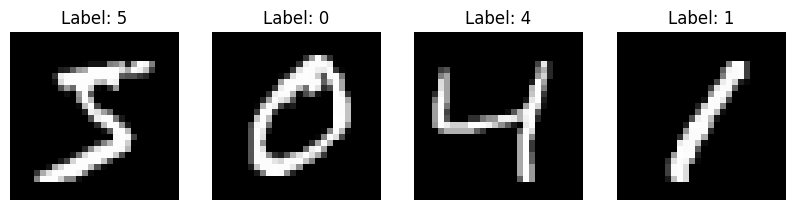

In [45]:
import matplotlib.pyplot as plt
from keras.datasets import mnist

# 重新加载原始形状的数据以便显示
(train_images_raw, train_labels_raw), _ = mnist.load_data()

plt.figure(figsize=(10, 4))
for i in range(4):
    plt.subplot(1, 4, i + 1)
    plt.imshow(train_images_raw[i], cmap='gray')
    plt.title(f"Label: {train_labels_raw[i]}")
    plt.axis('off')
plt.show()

In [46]:
train_images.shape

(60000, 28, 28)

In [47]:
len(train_labels)

60000

In [48]:
train_labels

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

In [49]:
test_images.shape

(10000, 28, 28)

In [50]:
len(test_labels)

10000

In [51]:
test_labels

array([7, 2, 1, ..., 4, 5, 6], dtype=uint8)

In [52]:
import keras
from keras import layers

model = keras.Sequential(
    [
        layers.Dense(512, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ]
)

In [53]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

In [54]:
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255
test_images = test_images.reshape((10000, 28 * 28))
test_images = test_images.astype("float32") / 255

In [55]:
model.fit(train_images, train_labels, epochs=5, batch_size=128)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9237 - loss: 0.2670
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9688 - loss: 0.1096
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9789 - loss: 0.0710
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9846 - loss: 0.0514
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9891 - loss: 0.0373


In [56]:
# 选择测试集中的前10个数字
test_digits = test_images[0:10]
# 使用模型对这些数字进行预测
predictions = model.predict(test_digits)
# 查看第一个测试样本的预测结果（概率分布）
predictions[0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step


array([1.3008595e-06, 1.8211787e-07, 2.1119233e-05, 1.4500470e-03,
       2.2130000e-09, 5.9155047e-07, 4.6582033e-11, 9.9850589e-01,
       3.7545071e-06, 1.6990298e-05], dtype=float32)

In [57]:
# 找出预测概率最高的类别索引
predictions[0].argmax()

np.int64(7)

In [58]:
# 确认索引为7的预测概率值
predictions[0][7]

np.float32(0.9985059)

In [59]:
# 查看测试集中第一个标签的真实值
test_labels[0]

np.uint8(7)

In [60]:
test_loss, test_acc = model.evaluate(test_images, test_labels)
print(f"test_acc: {test_acc}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9785 - loss: 0.0663
test_acc: 0.9785000085830688


### 使用自己的手写数字图片进行预测
请运行以下单元格并上传一张包含手写数字的图片（建议背景简单，数字清晰）。

Saving 7.png to 7.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 32467 (\N{CJK UNIFIED IDEOGRAPH-7ED3}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 26524 (\N{CJK UNIFIED IDEOGRAPH-679C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 32622 (\N{CJK UNIFIED IDEOGRAPH-7F6E}) missing from font(s) DejaVu Sans.
  fig.canvas

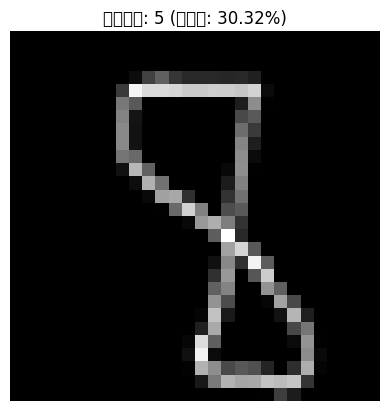

In [61]:
from google.colab import files
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# 1. 上传文件
uploaded = files.upload()

for filename in uploaded.keys():
    # 2. 读取并预处理图片
    img = Image.open(filename).convert('L') # 转为灰度图
    img = img.resize((28, 28)) # 调整为 MNIST 标准尺寸

    # 转换为数组
    img_array = np.array(img)

    # 关键步骤：MNIST 是黑底白字。如果你的图片是白底黑字，需要反转颜色
    # 我们通过检查中心区域的平均亮度来简单判断是否需要反转
    if np.mean(img_array) > 127:
        img_array = 255 - img_array

    # 归一化与展平 (匹配之前模型的输入格式)
    img_input = img_array.reshape(1, 28 * 28).astype("float32") / 255

    # 3. 预测
    prediction = model.predict(img_input)
    predicted_label = np.argmax(prediction)
    confidence = np.max(prediction)

    # 4. 可视化结果
    plt.imshow(img_array, cmap='gray')
    plt.title(f"预测结果: {predicted_label} (置信度: {confidence:.2%})")
    plt.axis('off')
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 20462 (\N{CJK UNIFIED IDEOGRAPH-4FEE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 27491 (\N{CJK UNIFIED IDEOGRAPH-6B63}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 21518 (\N{CJK UNIFIED IDEOGRAPH-540E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 27010 (\N{CJK UNIFIED IDEOGRAPH-6982}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  fig.canvas

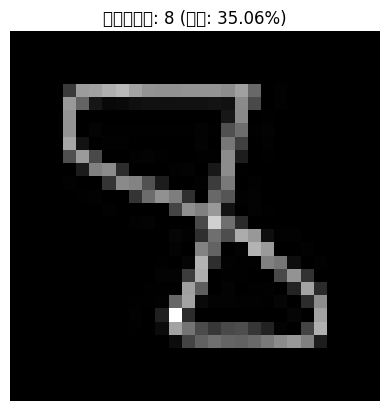

In [62]:
from PIL import Image, ImageOps
import numpy as np
import matplotlib.pyplot as plt

def robust_predict(filename):
    # 1. 加载并转为灰度
    img = Image.open(filename).convert('L')

    # 2. 自动反转颜色：确保是黑底白字
    # MNIST 是黑底 (0) 白字 (255)
    img_array = np.array(img)
    if np.mean(img_array) > 127:
        img = ImageOps.invert(img)

    # 3. 核心改进：去除白边并居中 (模拟 MNIST 的预处理)
    # 找到有像素的边界框
    bbox = img.getbbox()
    if bbox:
        img = img.crop(bbox)

    # 缩放至 20x20 (保持比例)，然后放在 28x28 的中心
    img.thumbnail((20, 20), Image.Resampling.LANCZOS)
    new_img = Image.new('L', (28, 28), (0))
    offset = ((28 - img.size[0]) // 2, (28 - img.size[1]) // 2)
    new_img.paste(img, offset)

    # 4. 最终输入处理
    final_array = np.array(new_img)
    img_input = final_array.reshape(1, 28 * 28).astype("float32") / 255

    # 5. 预测
    prediction = model.predict(img_input)
    predicted_label = np.argmax(prediction)

    # 可视化
    plt.imshow(final_array, cmap='gray')
    plt.title(f"修正后预测: {predicted_label} (概率: {np.max(prediction):.2%})")
    plt.axis('off')
    plt.show()

# 使用之前上传的文件 '7.png'
robust_predict('7.png')

### 构建并训练卷积神经网络 (CNN)
CNN 模型更擅长处理图像空间特征，对于手写数字识别通常能达到 99% 以上的准确率。

In [65]:
from keras import layers, models

# 1. 准备数据 (CNN 需要 4D 输入: [batch, height, width, channels])
(train_images_cnn, train_labels_cnn), _ = mnist.load_data()
train_images_cnn = train_images_cnn.reshape((60000, 28, 28, 1)).astype("float32") / 255

# 2. 构建 CNN 模型
cnn_model = models.Sequential([
    # 解释为什么使用 Conv2D 以及如何选择卷积层：
    # 图像数据通常是二维的（高度和宽度），Conv2D 层专门设计用于处理这类空间结构的数据。
    # 它通过在输入图像上滑动一个二维卷积核（或称为过滤器），提取图像中的局部特征（如边缘、纹理等）。
    # 相比于全连接层，Conv2D 具有以下优势：
    # 1. 局部感受野：每个神经元只连接到输入数据的一个局部区域，减少了模型参数。
    # 2. 权值共享：同一个卷积核在图像的不同区域重复使用，进一步减少了参数，并使模型对特征的位置不敏感（平移不变性）。
    # 3. 提取空间层次特征：通过堆叠多个 Conv2D 层，可以逐步提取更复杂、更抽象的图像特征。
    #
    # 如何判断该用哪种卷积层：
    # - Conv1D (一维卷积): 通常用于序列数据（如文本、音频、时间序列数据），其中特征是沿着一个时间或空间维度展开的。
    #   例如，处理一段文本时，卷积核在一个句子上滑动，捕捉词语的局部模式。
    # - Conv2D (二维卷积): 最常用于图像数据，因为图像本身是二维的。卷积核在图像的宽度和高度上滑动。
    #   例如，本例中处理 MNIST 手写数字图像。
    # - Conv3D (三维卷积): 用于视频数据（时间+高度+宽度）或 3D 医疗影像等具有三个空间/时空维度的数据。
    #   卷积核在三个维度上滑动，捕捉更复杂的多维模式。
    #
    # 总结：对于像 MNIST 这样的二维图像分类任务，`layers.Conv2D` 是标准的、也是最合适的选择。
    layers.Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

# 3. 编译与训练
cnn_model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

cnn_model.fit(train_images_cnn, train_labels_cnn, epochs=5, batch_size=64)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9470 - loss: 0.1697
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9847 - loss: 0.0491
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9891 - loss: 0.0354
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9917 - loss: 0.0268
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9927 - loss: 0.0230


### 用训练好的 CNN 再次预测你的图片
现在我们看看这个更强大的模型能否认出你的“7”。

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 32467 (\N{CJK UNIFIED IDEOGRAPH-7ED3}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 26524 (\N{CJK UNIFIED IDEOGRAPH-679C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 32622 (\N{CJK UNIFIED IDEOGRAPH-7F6E}) missing from font(s) DejaVu Sans.
  fig.canvas

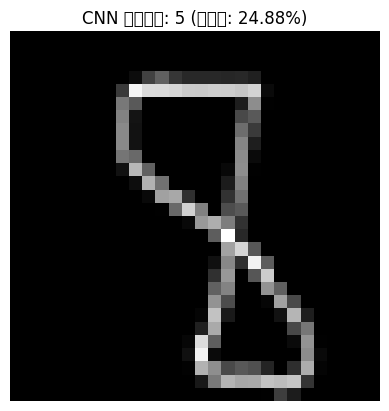

In [66]:
def cnn_predict(filename):
    img = Image.open(filename).convert('L')
    # 简单的预处理以匹配 CNN 输入
    if np.mean(np.array(img)) > 127: img = ImageOps.invert(img)
    img = img.resize((28, 28))
    img_input = np.array(img).reshape(1, 28, 28, 1).astype("float32") / 255

    pred = cnn_model.predict(img_input)
    plt.imshow(img, cmap='gray')
    plt.title(f"CNN 预测结果: {np.argmax(pred)} (置信度: {np.max(pred):.2%})")
    plt.axis('off')
    plt.show()

cnn_predict('7.png')

### Data representations for neural networks
### 神经网络的数据表示

#### Scalars (rank-0 tensors)
#### 标量（0阶张量）

In [ ]:
import numpy as np
x = np.array(12)
x

array(12)

In [ ]:
x.ndim

0

#### Vectors (rank-1 tensors)
#### 向量（1阶张量）

In [ ]:
x = np.array([12, 3, 6, 14, 7])
x

array([12,  3,  6, 14,  7])

In [ ]:
x.ndim

1

#### Matrices (rank-2 tensors)
#### 矩阵（2阶张量）

In [ ]:
x = np.array([[5, 78, 2, 34, 0],
              [6, 79, 3, 35, 1],
              [7, 80, 4, 36, 2]])
x.ndim

2

#### Rank-3 tensors and higher-rank tensors
#### 3阶张量及更高阶张量

In [ ]:
x = np.array([[[5, 78, 2, 34, 0],
               [6, 79, 3, 35, 1],
               [7, 80, 4, 36, 2]],
              [[5, 78, 2, 34, 0],
               [6, 79, 3, 35, 1],
               [7, 80, 4, 36, 2]],
              [[5, 78, 2, 34, 0],
               [6, 79, 3, 35, 1],
               [7, 80, 4, 36, 2]]])
x.ndim

3

#### Key attributes
#### 关键属性

In [ ]:
from keras.datasets import mnist

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

In [ ]:
train_images.ndim

3

In [ ]:
train_images.shape

(60000, 28, 28)

In [ ]:
train_images.dtype

dtype('uint8')

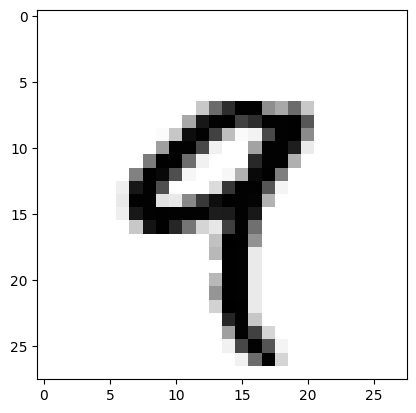

In [ ]:
import matplotlib.pyplot as plt

digit = train_images[4]
plt.imshow(digit, cmap=plt.cm.binary)
plt.show()

In [ ]:
train_labels[4]

np.uint8(9)

#### Manipulating tensors in NumPy
#### 在 NumPy 中操作张量

In [ ]:
my_slice = train_images[10:100]
my_slice.shape

(90, 28, 28)

In [ ]:
my_slice = train_images[10:100, :, :]
my_slice.shape

(90, 28, 28)

In [ ]:
my_slice = train_images[10:100, 0:28, 0:28]
my_slice.shape

(90, 28, 28)

In [ ]:
my_slice = train_images[:, 14:, 14:]
my_slice.shape

(60000, 14, 14)

In [ ]:
# 这个操作是从 28x28 的图片中切出中心 14x14 的区域
# [所有图片, 高度从第7到倒数第7, 宽度从第7到倒数第7]
my_slice = train_images[:, 7:-7, 7:-7]
print(f"切片后的形状: {my_slice.shape}")

切片后的形状: (60000, 14, 14)


#### The notion of data batches
#### 数据批次的概念

In [ ]:
batch = train_images[:128]

In [ ]:
batch = train_images[128:256]

In [ ]:
n = 3
batch = train_images[128 * n : 128 * (n + 1)]

#### Real-world examples of data tensors
#### 现实世界中的数据张量示例

##### Vector data
##### 向量数据

##### Timeseries data or sequence data
##### 时间序列数据或序列数据

##### Image data
##### 图像数据

##### Video data
##### 视频数据

### The gears of neural networks: Tensor operations
### 神经网络的齿轮：张量运算

#### Element-wise operations
#### 逐元素运算

In [ ]:
def naive_relu(x):
    # 确保输入 x 是一个 2 阶张量（矩阵）
    assert len(x.shape) == 2
    # 备份输入张量，避免原地修改原数据
    x = x.copy()
    # 遍历矩阵的行
    for i in range(x.shape[0]):
        # 遍历矩阵的列
        for j in range(x.shape[1]):
            # 对每个元素执行 ReLU 操作：如果小于 0 则置为 0
            x[i, j] = max(x[i, j], 0)
    return x

In [ ]:
def naive_add(x, y):
    # 确保输入 x 是一个 2 阶张量（矩阵）
    assert len(x.shape) == 2
    # 确保 x 和 y 的形状相同，这样才能进行逐元素相加
    assert x.shape == y.shape
    # 备份输入张量，避免原地修改原数据
    x = x.copy()
    # 遍历矩阵的行
    for i in range(x.shape[0]):
        # 遍历矩阵的列
        for j in range(x.shape[1]):
            # 将 y 中对应位置的元素加到 x 上
            x[i, j] += y[i, j]
    return x

### 性能对比：NumPy 向量化 vs. Python 原生循环

接下来的两个单元格对比了实现相同逻辑（矩阵加法 + ReLU 激活）时，两种方式的运行速度：

1.  **NumPy 向量化 (`x + y`)**：直接调用底层编译好的 C 代码和 CPU 指令集（如 SIMD），并行处理整块数据，速度极快。
2.  **原生 Python 循环 (`naive_add`)**：在 Python 解释器层面逐个处理元素，每次迭代都有类型检查等额外开销，处理大规模张量时非常缓慢。

**结论**：在深度学习中，应始终优先使用框架（如 NumPy、TensorFlow、Keras）提供的向量化运算。

In [ ]:
import time

# 创建两个大的随机矩阵用于性能测试
x = np.random.random((20, 100))
y = np.random.random((20, 100))

t0 = time.time()
# 循环执行 1000 次，测试 NumPy 内置运算的耗时
for _ in range(1000):
    # 逐元素加法
    z = x + y
    # 逐元素取最大值 (ReLU)
    z = np.maximum(z, 0.0)
print("Took: {0:.2f} s".format(time.time() - t0))

Took: 0.01 s


In [ ]:
t0 = time.time()
# 循环执行 1000 次，测试手写 Python 循环函数的耗时
for _ in range(1000):
    # 调用手写的逐元素加法
    z = naive_add(x, y)
    # 调用手写的逐元素 ReLU
    z = naive_relu(z)
print("Took: {0:.2f} s".format(time.time() - t0))

Took: 1.58 s


#### Broadcasting
#### 广播

In [ ]:
import numpy as np

X = np.random.random((32, 10))
y = np.random.random((10,))
y

array([0.27149256, 0.33072232, 0.17474241, 0.53129616, 0.36644713,
       0.47055962, 0.94980881, 0.8592956 , 0.31578248, 0.81285106])

In [ ]:
y = np.expand_dims(y, axis=0)
y

array([[0.27149256, 0.33072232, 0.17474241, 0.53129616, 0.36644713,
        0.47055962, 0.94980881, 0.8592956 , 0.31578248, 0.81285106]])

In [ ]:
# 将向量 y 沿着第 0 轴（行）方向重复 32 次，沿着第 1 轴（列）方向重复 1 次
# 这会创建一个形状为 (32, 10) 的矩阵，模拟广播机制中的扩展操作
Y = np.tile(y, (32, 1))
Y

array([[0.27149256, 0.33072232, 0.17474241, 0.53129616, 0.36644713,
        0.47055962, 0.94980881, 0.8592956 , 0.31578248, 0.81285106],
       [0.27149256, 0.33072232, 0.17474241, 0.53129616, 0.36644713,
        0.47055962, 0.94980881, 0.8592956 , 0.31578248, 0.81285106],
       [0.27149256, 0.33072232, 0.17474241, 0.53129616, 0.36644713,
        0.47055962, 0.94980881, 0.8592956 , 0.31578248, 0.81285106],
       [0.27149256, 0.33072232, 0.17474241, 0.53129616, 0.36644713,
        0.47055962, 0.94980881, 0.8592956 , 0.31578248, 0.81285106],
       [0.27149256, 0.33072232, 0.17474241, 0.53129616, 0.36644713,
        0.47055962, 0.94980881, 0.8592956 , 0.31578248, 0.81285106],
       [0.27149256, 0.33072232, 0.17474241, 0.53129616, 0.36644713,
        0.47055962, 0.94980881, 0.8592956 , 0.31578248, 0.81285106],
       [0.27149256, 0.33072232, 0.17474241, 0.53129616, 0.36644713,
        0.47055962, 0.94980881, 0.8592956 , 0.31578248, 0.81285106],
       [0.27149256, 0.33072232, 0.1747424

In [ ]:
'''
这段代码展示了矩阵与向量相加的底层实现逻辑。
在深度学习中，这通常对应于给神经元的输出加上偏置项（bias）。

它的核心操作是：将一个一维向量 y 加到二维矩阵 x 的每一行上。
虽然 NumPy 可以用 x + y 一行代码自动搞定（即“广播”），
但这里的代码通过循环让你看清内部发生了什么：
它遍历矩阵的每一行，然后把向量里的元素对应地加进去。
'''
def naive_add_matrix_and_vector(x, y):
    # 确保 x 是矩阵（2阶），y 是向量（1阶）
    assert len(x.shape) == 2
    assert len(y.shape) == 1
    # 确保矩阵的列数与向量的长度匹配，这样才能对齐相加
    assert x.shape[1] == y.shape[0]
    x = x.copy()
    # 遍历矩阵的每一行
    for i in range(x.shape[0]):
        # 遍历该行中的每一个元素
        for j in range(x.shape[1]):
            # 将向量 y 的第 j 个元素加到矩阵第 i 行的第 j 个元素上
            x[i, j] += y[j]
    return x

In [ ]:
import numpy as np

x = np.random.random((64, 3, 32, 10))
y = np.random.random((32, 10))
z = np.maximum(x, y)

#### Tensor product
#### 张量积

In [ ]:
import numpy as np

# 定义两个具体的向量 (1D 张量)
x = np.array([1, 2, 3])
y = np.array([4, 5, 6])

# 计算点积：1*4 + 2*5 + 3*6 = 4 + 10 + 18 = 32
# 方式1：使用 np.matmul
z1 = np.matmul(x, y)

# 方式2：使用 @ 运算符 (在 Python 中等同于点积)
z2 = x @ y

print(f"向量 x: {x}")
print(f"向量 y: {y}")
print(f"点积结果 (z1): {z1}")
print(f"点积结果 (z2): {z2}")

向量 x: [1 2 3]
向量 y: [4 5 6]
点积结果 (z1): 32
点积结果 (z2): 32


In [ ]:
def naive_vector_product(x, y):
    assert len(x.shape) == 1
    assert len(y.shape) == 1
    assert x.shape[0] == y.shape[0]
    z = 0.0
    for i in range(x.shape[0]):
        z += x[i] * y[i]
    return z

In [ ]:
def naive_matrix_vector_product(x, y):
    """
    目的：手动实现矩阵 (2D 张量) 与向量 (1D 张量) 的乘积。
    结果是一个新的向量，其每个元素是矩阵的一行与输入向量的点积。
    """
    # 确保 x 是矩阵，y 是向量
    assert len(x.shape) == 2
    assert len(y.shape) == 1
    # 矩阵的列数必须等于向量的长度（维度匹配）
    assert x.shape[1] == y.shape[0]

    # 初始化结果向量，长度等于矩阵的行数，初始值为 0
    z = np.zeros(x.shape[0])

    # 遍历矩阵的每一行
    for i in range(x.shape[0]):
        # 遍历该行的每一个元素，并与向量 y 对应位置元素相乘
        for j in range(x.shape[1]):
            # 累加乘积：z[i] = x[i, 0]*y[0] + x[i, 1]*y[1] + ...
            z[i] += x[i, j] * y[j]
    return z

In [ ]:
def naive_matrix_vector_product(x, y):
    """
    目的：手动实现矩阵 (2D 张量) 与向量 (1D 张量) 的乘积。
    此实现通过复用已定义的 naive_vector_product 函数，
    将矩阵的每一行看作一个向量来处理。
    """
    # 初始化结果向量，长度等于矩阵的行数
    z = np.zeros(x.shape[0])
    # 遍历矩阵的每一行
    for i in range(x.shape[0]):
        # 取出矩阵的第 i 行，并与向量 y 计算点积
        # x[i, :] 表示提取矩阵中索引为 i 的那一整行
        z[i] = naive_vector_product(x[i, :], y)
    return z

In [ ]:
def naive_matrix_product(x, y):
    """
    目的：手动实现两个矩阵 (2D 张量) 的乘积。
    结果是一个新矩阵，其元素 z[i, j] 是 x 的第 i 行与 y 的第 j 列的点积。
    """
    # 确保两个输入都是 2 阶张量（矩阵）
    assert len(x.shape) == 2
    assert len(y.shape) == 2
    # 矩阵乘法的核心要求：第一个矩阵的列数必须等于第二个矩阵的行数
    assert x.shape[1] == y.shape[0]

    # 初始化结果矩阵，形状为 (x 的行数, y 的列数)
    z = np.zeros((x.shape[0], y.shape[1]))

    # 遍历第一个矩阵的每一行
    for i in range(x.shape[0]):
        # 遍历第二个矩阵的每一列
        for j in range(y.shape[1]):
            # 提取 x 的第 i 行
            row_x = x[i, :]
            # 提取 y 的第 j 列
            column_y = y[:, j]
            # 计算这两者的点积，并赋值给结果矩阵的对应位置
            z[i, j] = naive_vector_product(row_x, column_y)
    return z

#### Tensor reshaping
#### 张量变型

In [ ]:
train_images = train_images.reshape((60000, 28 * 28))

In [ ]:
x = np.array([[0., 1.],
              [2., 3.],
              [4., 5.]])
x.shape

(3, 2)

In [ ]:
x = x.reshape((6, 1))
x

array([[0.],
       [1.],
       [2.],
       [3.],
       [4.],
       [5.]])

In [ ]:
x = x.reshape((2, 3))
x

array([[0., 1., 2.],
       [3., 4., 5.]])

In [ ]:
x = np.zeros((300, 20))
x = np.transpose(x)
x.shape

(20, 300)

#### Geometric interpretation of tensor operations
#### 张量运算的几何解释

#### A geometric interpretation of deep learning
#### 深度学习的几何解释

### The engine of neural networks: Gradient-based optimization
### 神经网络的引擎：基于梯度的优化

#### What's a derivative?
#### 什么是导数？

#### Derivative of a tensor operation: The gradient
#### 张量运算的导数：梯度

#### Stochastic gradient descent
#### 随机梯度下降

#### Chaining derivatives: The Backpropagation algorithm
#### 链式求导：反向传播算法

##### The chain rule
##### 链式法则

##### Automatic differentiation with computation graphs
##### 利用计算图进行自动微分

### Looking back at our first example
### 回顾我们的第一个例子

In [ ]:
"""
目的：预处理 MNIST 数据集。
1. 将 28x28 的二维图像展平为 784 维的一维向量，以符合全连接层（Dense）的输入要求。
2. 将像素值归一化到 [0, 1] 区间，有助于模型更快收敛。
"""
# 加载 MNIST 数据集
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

# 将训练图像从 (60000, 28, 28) 重塑为 (60000, 784)
train_images = train_images.reshape((60000, 28 * 28))
# 将数据类型转换为 float32 并执行归一化（除以 255）
train_images = train_images.astype("float32") / 255

# 对测试图像执行相同的重塑和归一化操作
test_images = test_images.reshape((10000, 28 * 28))
test_images = test_images.astype("float32") / 255

### 维度匹配的几何直观解释

当我们定义 `model = keras.Sequential([...])` 时，层与层之间的维度是严格锁定的：

| 层级 | 输入维度 (input_size) | 输出维度 (output_size) | 权重矩阵 W 的形状 |
| :--- | :--- | :--- | :--- |
| **Dense_1** | 784 (来自原始数据) | 512 (手动指定) | `(784, 512)` |
| **Dense_2** | 512 (来自上一层) | 10 (手动指定) | `(512, 10)` |

**为什么第一层不需要写 input_size？**  
在 Keras 中，如果你没有显式提供 `input_shape`，模型会在第一次看到数据（即调用 `fit` 时）自动通过数据的形状来推断第一层的 `input_size`。

In [ ]:
model = keras.Sequential(
    [
        layers.Dense(512, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ]
)

In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

In [ ]:
model.fit(
    train_images,
    train_labels,
    epochs=5,
    batch_size=128,
)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9234 - loss: 0.2685
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9692 - loss: 0.1074
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9790 - loss: 0.0710
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9857 - loss: 0.0499
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9891 - loss: 0.0367


#### Reimplementing our first example from scratch
#### 从头开始重新实现我们的第一个例子

##### A simple Dense class
##### 一个简单的 Dense 类

In [ ]:
import keras
from keras import ops

class NaiveDense:
    """
    目的：手动实现一个简单的全连接层（Dense Layer）。
    该类模拟了 Keras 层的工作方式：
    1. 维护可学习的权重参数 (W 和 b)。
    2. 实现前向传播逻辑：计算输入与权重的点积，加上偏置，并应用激活函数。
    """
    def __init__(self, input_size, output_size, activation=None):
        self.activation = activation

        # TODO 这里的两个维度大小我不理解，应该差不多了
        # 初始化权重 W，形状为 (输入维度, 输出维度)，初始值为随机均匀分布
        self.W = keras.Variable(
            shape=(input_size, output_size), initializer="uniform"
        )
        # 初始化偏置 b，形状为 (输出维度,)，初始值为 0
        self.b = keras.Variable(shape=(output_size,), initializer="zeros")

    def __call__(self, inputs):
        # 1. 计算矩阵乘法 (dot product)
        x = ops.matmul(inputs, self.W)
        # 2. 加上偏置 (利用广播机制)
        x = x + self.b
        # 3. 如果指定了激活函数，则应用它
        if self.activation is not None:
            x = self.activation(x)
        return x

    @property
    def weights(self):
        # 返回该层的所有可训练权重，方便后续梯度下降更新
        return [self.W, self.b]

##### A simple Sequential class
##### 一个简单的 Sequential 类

In [ ]:
class NaiveSequential:
    """
    目的：手动实现一个简单的顺序模型容器（Sequential Model）。
    该类模拟了 Keras 的 Sequential 模型，通过串联多个层级来构建神经网络：
    1. 接收一个层列表并将它们存储起来。
    2. 按顺序调用这些层，将前一层的输出作为后一层的输入。
    3. 汇总所有层中的权重参数，以便进行梯度更新。
    """
    def __init__(self, layers):
        # 存储传入的层列表（如多个 NaiveDense 实例）
        self.layers = layers

    def __call__(self, inputs):
        # 前向传播：将输入数据依次流经每一层
        x = inputs
        for layer in self.layers:
            x = layer(x)
        return x

    @property
    def weights(self):
        # 权重汇总：遍历所有层，收集它们各自的 weights (W 和 b)
        weights = []
        for layer in self.layers:
            weights += layer.weights
        return weights

In [ ]:
model = NaiveSequential(
    [
        NaiveDense(input_size=28 * 28, output_size=512, activation=ops.relu),
        NaiveDense(input_size=512, output_size=10, activation=ops.softmax),
    ]
)
assert len(model.weights) == 4

##### A batch generator
##### 一个批次生成器

In [ ]:
import math

class BatchGenerator:
    """
    目的：创建一个批次迭代器，用于将数据集拆分为固定大小的小批量（mini-batches）。
    这是训练深度学习模型的标准做法，可以减少内存占用并提高梯度下降的稳定性。
    """
    def __init__(self, images, labels, batch_size=128):
        # 确保图像和标签的数量对等
        assert len(images) == len(labels)
        self.index = 0
        self.images = images
        self.labels = labels
        self.batch_size = batch_size
        # 计算总共有多少个批次（向上取整）
        self.num_batches = math.ceil(len(images) / batch_size)

    def next(self):
        # 提取从当前索引到当前索引+批次大小的数据切片
        images = self.images[self.index : self.index + self.batch_size]
        labels = self.labels[self.index : self.index + self.batch_size]
        # 更新索引，为获取下一个批次做准备
        self.index += self.batch_size
        return images, labels

#### Running one training step
#### 运行一个训练步骤

##### The weight update step
##### 权重更新步骤

In [ ]:
learning_rate = 1e-3

def update_weights(gradients, weights):
    """
    目的：执行权重更新步骤（梯度下降）。
    根据计算出的梯度，按照指定的学习率比例，反方向调整模型参数（权重），以降低损失函数的值。
    """
    # 遍历每一对梯度和对应的权重张量
    for g, w in zip(gradients, weights):
        # assign 方法用于原地修改权重值
        # w = w - gradient * learning_rate
        w.assign(w - g * learning_rate)

In [ ]:
from keras import optimizers

# 初始化一个随机梯度下降 (SGD) 优化器
optimizer = optimizers.SGD(learning_rate=1e-3)

def update_weights(gradients, weights):
    """
    目的：使用 Keras 内置优化器更新模型权重。
    相比手动减去梯度，使用优化器可以更方便地切换不同的优化算法（如 Adam, RMSprop）。
    """
    # 将计算出的梯度应用到对应的权重张量上
    optimizer.apply_gradients(zip(gradients, weights))

##### Gradient computation
##### 梯度计算

In [ ]:
%%backend tensorflow
import tensorflow as tf

"""
目的：演示 TensorFlow 的自动微分机制（GradientTape）。
通过记录计算图，TensorFlow 能够自动计算出复杂函数相对于其输入变量的导数。
"""
x = tf.zeros(shape=())
# 在 GradientTape 的上下文中执行运算，以便记录梯度
with tf.GradientTape() as tape:
    # 必须让 tape 监视常数 x，因为默认只监视 Variable
    tape.watch(x)
    y = 2 * x + 3
# 计算 y 相对于 x 的梯度 (dy/dx)
grad_of_y_wrt_x = tape.gradient(y, x)

# 由于使用了 %%backend 魔法命令，需要显式 print 才能看到输出
print(f"梯度值: {grad_of_y_wrt_x}")

梯度值: 2.0


In [ ]:
%%backend tensorflow
def one_training_step(model, images_batch, labels_batch):
    """
    目的：执行单个批次的训练循环。
    包含四个步骤：前向传播、计算损失、反向传播（梯度计算）、更新权重。
    """
    with tf.GradientTape() as tape:
        # 1. 前向传播：计算模型对当前批次的预测值
        predictions = model(images_batch)
        # 2. 计算损失：衡量预测值与真实标签之间的差距
        loss = ops.sparse_categorical_crossentropy(labels_batch, predictions)
        # 计算该批次的平均损失
        average_loss = ops.mean(loss)

    # 3. 反向传播：计算损失函数相对于模型所有可训练权重的梯度
    gradients = tape.gradient(average_loss, model.weights)

    # 4. 更新权重：根据梯度调整参数
    update_weights(gradients, model.weights)

    # 返回当前批次的损失值，用于监控训练进度
    return average_loss

#### The full training loop
#### 完整的训练循环

In [ ]:
%%backend tensorflow
def fit(model, images, labels, epochs, batch_size=128):
    """
    目的：手动实现模型的完整训练过程（训练循环）。
    逻辑：
    1. 遍历指定的训练轮次 (epochs)。
    2. 在每一轮中，使用 BatchGenerator 将数据切分为批次。
    3. 对每个批次调用 one_training_step 进行权重更新，并打印实时损失。
    """
    for epoch_counter in range(epochs):
        print(f"Epoch {epoch_counter}")
        # 初始化本轮的批次生成器
        batch_generator = BatchGenerator(images, labels)
        for batch_counter in range(batch_generator.num_batches):
            # 获取下一个批次的训练数据
            images_batch, labels_batch = batch_generator.next()
            # 执行一次训练步：前向传播 + 计算梯度 + 更新参数
            loss = one_training_step(model, images_batch, labels_batch)
            # 每隔 100 个批次打印一次损失，方便观察收敛情况
            if batch_counter % 100 == 0:
                print(f"loss at batch {batch_counter}: {loss:.2f}")

In [ ]:
%%backend tensorflow
from keras.datasets import mnist

"""
目的：整合之前的所有手动实现，在真实 MNIST 数据上运行训练。
这会调用我们自己写的 fit 函数、one_training_step 和 NaiveDense 层。
"""
# 加载数据并执行预处理（展平与归一化）
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255
test_images = test_images.reshape((10000, 28 * 28))
test_images = test_images.astype("float32") / 255

# 启动训练：训练 10 轮，每批次 128 个样本
fit(model, train_images, train_labels, epochs=10, batch_size=128)

Epoch 0
loss at batch 0: 2.32
loss at batch 100: 2.29
loss at batch 200: 2.25
loss at batch 300: 2.21
loss at batch 400: 2.17
Epoch 1
loss at batch 0: 2.14
loss at batch 100: 2.14
loss at batch 200: 2.08
loss at batch 300: 2.05
loss at batch 400: 2.00
Epoch 2
loss at batch 0: 1.96
loss at batch 100: 1.98
loss at batch 200: 1.90
loss at batch 300: 1.87
loss at batch 400: 1.82
Epoch 3
loss at batch 0: 1.77
loss at batch 100: 1.81
loss at batch 200: 1.71
loss at batch 300: 1.69
loss at batch 400: 1.64
Epoch 4
loss at batch 0: 1.58
loss at batch 100: 1.64
loss at batch 200: 1.51
loss at batch 300: 1.50
loss at batch 400: 1.47
Epoch 5
loss at batch 0: 1.39
loss at batch 100: 1.46
loss at batch 200: 1.33
loss at batch 300: 1.33
loss at batch 400: 1.31
Epoch 6
loss at batch 0: 1.23
loss at batch 100: 1.30
loss at batch 200: 1.16
loss at batch 300: 1.18
loss at batch 400: 1.18
Epoch 7
loss at batch 0: 1.09
loss at batch 100: 1.17
loss at batch 200: 1.03
loss at batch 300: 1.05
loss at batch 40

#### Evaluating the model
#### 评估模型

In [ ]:
%%backend tensorflow

"""
目的：评估手动实现的模型在测试集上的准确率性能。
通过对比模型预测结果与真实标签，计算分类正确的比例。
"""
# 1. 获得模型对测试集图片的预测概率分布
predictions = model(test_images)
# 2. 取出每个预测结果中概率最大的索引作为预测类别
predicted_labels = ops.argmax(predictions, axis=1)
# 3. 将预测标签与真实标签进行逐元素对比，得到布尔矩阵
matches = predicted_labels == test_labels
# 4. 计算布尔矩阵的均值即为准确率，并打印结果
print(f"最终准确率: {ops.mean(matches):.2f}")

最终准确率: 0.84
